#  📦 Cell 1 — Install Dependencies

In [1]:
# 🔥 CLEAN ENV (VERY IMPORTANT)
!pip uninstall -y transformers huggingface_hub tokenizers accelerate -q

# ✅ INSTALL PERFECTLY MATCHED VERSIONS
!pip install -q \
transformers==4.37.2 \
huggingface_hub==0.20.3 \
tokenizers==0.15.2 \
accelerate==0.25.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 73.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.1/330.1 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 90.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 20.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.8.3 requires huggingface-hub<2.0,>=0.25.0, but you have huggingface-hub 0.20.3 which is incompatible.
peft 0.18.1 requires huggingface_hub>=0.25.0, but you have huggingface-hub 0.20.3 which is incompatible.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.37.2 which is incompatible.
diffusers 0.36.0 requires huggingface-hub<2.0,>=0.34.0, but you have hug

 # ⏱ Cell 2 — Runtime Tracker Start

In [2]:
import time
training_start_time = time.time()
print("⏱ Runtime tracker started.")

⏱ Runtime tracker started.


# 📚 Cell 3 — Imports

In [3]:
# ============================
# IMPORTS + SPEED FIXES
# ============================
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_NO_TORCH_DISTRIBUTED"] = "1"

import json
import time
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, confusion_matrix, classification_report, accuracy_score, multilabel_confusion_matrix
from sklearn.model_selection import train_test_split

torch.backends.cudnn.benchmark = True

print("PyTorch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch Version: 2.10.0+cu128
GPU Available: True
Device: cuda


# ⚙️ Cell 4 — Configuration
 Change your hyperparameters here.

In [4]:
# ================================
# CONFIGURATION — CHANGE SETTINGS HERE
# ================================
CFG = {
    "model_name": "google/muril-base-cased",
    "max_len": 64,
    "batch_size": 64,
    "epochs": 30,
    "lr": 2e-5,
    "dropout": 0.3,
    "hidden_dim": 512,
    "seed": 42,
    "save_dir": "/kaggle/working/alankar_model",
    "data_path": "/kaggle/input/datasets/sagardewanjeeorg/alankarmini/single_line_groups_ngram.xlsx",
    "text_col": "Text",
    "label_col": "Detected Alankars",
}

THRESHOLD    = 0.5
TEST_SIZE    = 0.2
RANDOM_STATE = CFG["seed"]
EPOCHS       = CFG["epochs"]
BATCH_SIZE   = CFG["batch_size"]
LEARNING_RATE = CFG["lr"]

os.makedirs(CFG["save_dir"], exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LEARNING_RATE} | Threshold: {THRESHOLD}")
print(f"Model: {CFG['model_name']}")
print(f"Device: {DEVICE}")

Epochs: 30 | Batch: 64 | LR: 2e-05 | Threshold: 0.5
Model: google/muril-base-cased
Device: cuda


# 📂 Cell 5 — Load Dataset

In [5]:
def load_dataset(path):
    df = pd.read_excel(path).dropna()

    def parse(x):
        if isinstance(x, list):
            return x
        x = str(x)
        if x.startswith("["):
            return json.loads(x.replace("'", '"'))
        return [i.strip() for i in x.split(",")]

    df["labels"] = df[CFG["label_col"]].apply(parse)
    return df

df = load_dataset(CFG["data_path"])

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (21070, 6)
Columns: ['Poem ID', 'Title', 'Line Group', 'Text', 'Detected Alankars', 'labels']


,Poem ID,Title,Line Group,Text,Detected Alankars,labels
0,1,नया रास्ता (Naya Rasta),Lines 1 to 1,जब सारे जाने हुए रास्ते बंद हो जाते हैं,"Yamak, Anupras, Upma, Roopak","[Yamak, Anupras, Upma, Roopak]"
1,1,नया रास्ता (Naya Rasta),Lines 2 to 2,तो आदमी एक नए रास्ते के बारे में सोचता है,Roopak,[Roopak]
3,1,नया रास्ता (Naya Rasta),Lines 4 to 4,एक नए प्रयास के बारे में सोचता है,Roopak,[Roopak]
5,1,नया रास्ता (Naya Rasta),Lines 6 to 6,एक नई ताक़त से लगता है,"Upma, Utpreksha, Roopak","[Upma, Utpreksha, Roopak]"
6,1,नया रास्ता (Naya Rasta),Lines 7 to 7,एक नई ताक़त वाला आदमी बिल्कुल एक नया आदमी होता है,"Yamak, Anupras, Roopak","[Yamak, Anupras, Roopak]"


# 🏷️ Cell 6 — Preprocess Labels (MultiLabelBinarizer)

In [6]:
mlb = MultiLabelBinarizer()
Y   = mlb.fit_transform(df["labels"]).astype(np.float32)
X   = df[CFG["text_col"]].tolist()

num_classes = len(mlb.classes_)
print("Detected Alankar Classes:", mlb.classes_)
print("Number of Classes:", num_classes)
print("Label matrix shape:", Y.shape)

Detected Alankar Classes: ['Anupras' 'Roopak' 'Shlesh' 'Upma' 'Utpreksha' 'Virodhbhas' 'Yamak']
Number of Classes: 7
Label matrix shape: (21070, 7)


# 🤖 Cell 7 — Dataset & Model Definition (MuRIL Transformer)

In [7]:
# ============================
# DATASET (TOKENIZED ONCE)
# ============================
class AlankarDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=CFG["max_len"]
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx]),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float32)
        }

# ============================
# MODEL
# ============================
class Model(nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(CFG["model_name"])
        self.fc = nn.Sequential(
            nn.Dropout(CFG["dropout"]),
            nn.Linear(self.encoder.config.hidden_size, CFG["hidden_dim"]),
            nn.ReLU(),
            nn.Linear(CFG["hidden_dim"], num_labels)
        )

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state.mean(1)
        return self.fc(pooled)

# ============================
# METRICS HELPER
# ============================
def compute_accuracy(probs, labels):
    preds = (probs >= THRESHOLD).astype(int)
    return (preds == labels).mean()

print("✅ Dataset class, Model class, and accuracy helper defined.")

✅ Dataset class, Model class, and accuracy helper defined.


 # ✂️ Cell 8 — Train / Validation Split

In [8]:
X_tr, X_val, Y_tr, Y_val = train_test_split(
    X, Y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

tokenizer = AutoTokenizer.from_pretrained(CFG["model_name"])

ds_tr  = AlankarDataset(X_tr,  Y_tr,  tokenizer)
ds_val = AlankarDataset(X_val, Y_val, tokenizer)

dl_tr = DataLoader(
    ds_tr,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

dl_val = DataLoader(
    ds_val,
    batch_size=BATCH_SIZE,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

N = len(X)
print(f"Total samples   : {N}")
print(f"Train samples   : {len(X_tr)}  ({len(X_tr)/N*100:.1f}%)")
print(f"Val   samples   : {len(X_val)}  ({len(X_val)/N*100:.1f}%)")
print(f"✅ Tokenizer loaded: {CFG['model_name']}")

# Show per-label distribution to verify stratification
print("\nPer-label positive-sample counts:")
label_df = pd.DataFrame({
    'Label'     : mlb.classes_,
    'Train (pos)': Y_tr.sum(axis=0).astype(int),
    'Val   (pos)': Y_val.sum(axis=0).astype(int),
})
label_df['Val %'] = (label_df['Val   (pos)'] /
                     (label_df['Train (pos)'] + label_df['Val   (pos)']) * 100).round(1)
print(label_df.to_string(index=False))

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

Total samples   : 21070
Train samples   : 16856  (80.0%)
Val   samples   : 4214  (20.0%)
✅ Tokenizer loaded: google/muril-base-cased

Per-label positive-sample counts:
     Label  Train (pos)  Val   (pos)  Val %
   Anupras         5563         1411   20.2
    Roopak         8643         2136   19.8
    Shlesh          229           61   21.0
      Upma         7330         1836   20.0
 Utpreksha          444          124   21.8
Virodhbhas          250           63   20.1
     Yamak         3498          850   19.5


# 🏗️ Cell 9 — Build Model

In [9]:
model     = Model(num_classes).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler    = torch.cuda.amp.GradScaler()

print("✅ MuRIL model built and moved to device.")
print(f"   Encoder hidden size : {model.encoder.config.hidden_size}")
print(f"   Hidden dim          : {CFG['hidden_dim']}")
print(f"   Dropout             : {CFG['dropout']}")
print(f"   Output classes      : {num_classes}")

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

✅ MuRIL model built and moved to device.
   Encoder hidden size : 768
   Hidden dim          : 512
   Dropout             : 0.3
   Output classes      : 7


/tmp/ipykernel_55/3501404735.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler()


#  🔔 Cell 10 — Define Callbacks / Early Stopping Config

In [10]:
# Early stopping parameters
patience_same_limit = 5   # stop if val_loss stays same for N epochs
patience_inc_limit  = 3   # stop if val_loss increases for N epochs

best_loss      = float("inf")
best_epoch     = 0
patience_same  = 0
patience_inc   = 0

# History lists
train_loss_hist, val_loss_hist = [], []
train_acc_hist,  val_acc_hist  = [], []
f1_hist = []

print("✅ Early Stopping config set:")
print(f"   patience_same : {patience_same_limit} epochs")
print(f"   patience_inc  : {patience_inc_limit} epochs")
print(f"   Checkpoint path: {CFG['save_dir']}/best_model.pt")

✅ Early Stopping config set:
   patience_same : 5 epochs
   patience_inc  : 3 epochs
   Checkpoint path: /kaggle/working/alankar_model/best_model.pt


# ⚖️ Cell 10.5 — Compute Label Weights (Class Imbalance)
Inverse-frequency weights + manual boosts for Virodhbhas, Utpreksha,Shlesh(same strategy as tf-idf-590k).

In [11]:
# ════════════════════════════════════════════════════════════════
# Compute per-label weights to address class imbalance
# Strategy: inverse frequency + manual boosts (from tf-idf-590k)
# ════════════════════════════════════════════════════════════════

# ── 1. Base inverse-frequency weights ───────────────────────────────────────
# Formula: N_train / (num_classes * label_count_per_class)
# Rare labels get higher weight, frequent ones get lower weight
label_counts  = Y_tr.sum(axis=0)   # shape: (num_classes,)
label_weights = np.where(
    label_counts > 0,
    len(Y_tr) / (num_classes * label_counts),
    1.0
)

print("Base inverse-frequency weights:")
for cls, w, cnt in zip(mlb.classes_, label_weights, label_counts.astype(int)):
    print(f"   {cls:<15} count={cnt:>6}   weight={w:.4f}")

# ── 2. Manual boosts for the 3 minority classes ─────────────────────────────
# Find indices dynamically (safe regardless of class ordering)
class_list = list(mlb.classes_)

idx_virodhbhas = class_list.index("Virodhbhas") if "Virodhbhas" in class_list else None
idx_utpreksha  = class_list.index("Utpreksha")  if "Utpreksha"  in class_list else None
idx_shlesh     = class_list.index("Shlesh")     if "Shlesh"     in class_list else None

if idx_virodhbhas is not None:
    label_weights[idx_virodhbhas] = 5.0   # High penalty for missing Virodhbhas
    print(f"\n🔴 Boosted Virodhbhas  (idx {idx_virodhbhas}) → weight = 5.0")
if idx_utpreksha is not None:
    label_weights[idx_utpreksha]  = 4.0   # High penalty for missing Utpreksha
    print(f"🟠 Boosted Utpreksha   (idx {idx_utpreksha}) → weight = 4.0")
if idx_shlesh is not None:
    label_weights[idx_shlesh]     = 5.0   # Moderate boost for Shlesh
    print(f"🟡 Boosted Shlesh      (idx {idx_shlesh}) → weight =5.0")

# ── 3. Convert to torch tensor ───────────────────────────────────────────────
label_weights_tensor = torch.tensor(label_weights, dtype=torch.float32).to(DEVICE)

print("\n✅ Final label weights:")
for cls, w in zip(mlb.classes_, label_weights):
    print(f"   {cls:<15}  weight = {w:.4f}")

Base inverse-frequency weights:
   Anupras         count=  5563   weight=0.4329
   Roopak          count=  8643   weight=0.2786
   Shlesh          count=   229   weight=10.5153
   Upma            count=  7330   weight=0.3285
   Utpreksha       count=   444   weight=5.4234
   Virodhbhas      count=   250   weight=9.6320
   Yamak           count=  3498   weight=0.6884

🔴 Boosted Virodhbhas  (idx 5) → weight = 5.0
🟠 Boosted Utpreksha   (idx 4) → weight = 4.0
🟡 Boosted Shlesh      (idx 2) → weight =5.0

✅ Final label weights:
   Anupras          weight = 0.4329
   Roopak           weight = 0.2786
   Shlesh           weight = 5.0000
   Upma             weight = 0.3285
   Utpreksha        weight = 4.0000
   Virodhbhas       weight = 5.0000
   Yamak            weight = 0.6884


#  🚀 Cell 11 — Train Model

In [12]:
# ════════════════════════════════════════════════════════════════
# Cell 11 — Train Model with Cost-Sensitive Sample Weights
# ════════════════════════════════════════════════════════════════

def get_sample_weights(y_batch_np, lw):
    """
    For each sample, compute scalar weight = mean of its positive label weights.
    If a sample has no positive label, weight = 1.0
    Mirrors the tf-idf-590k approach exactly.
    """
    sw = np.array([
        lw[y_batch_np[j].astype(bool)].mean() if y_batch_np[j].sum() > 0 else 1.0
        for j in range(len(y_batch_np))
    ], dtype=np.float32)
    return sw

for ep in range(EPOCHS):
    print(f"\nEpoch {ep+1}/{EPOCHS}")

    # ================= TRAIN =================
    model.train()
    tr_loss = 0
    train_probs_list, train_labels_list = [], []

    for batch in tqdm(dl_tr, desc="Training"):
        optimizer.zero_grad()

        input_ids      = batch["input_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        labels         = batch["labels"].to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast():
            logits = model(input_ids, attention_mask)

            # ── Cost-sensitive loss with sample weights ──────────────────────
            # 1. Raw per-sample, per-label BCE loss (no reduction)
            raw_loss = torch.nn.functional.binary_cross_entropy_with_logits(
                logits, labels, reduction="none"
            )  # shape: (batch, num_classes)

            # 2. Compute scalar sample weights from label_weights_tensor
            #    weight_per_sample = mean weight over the sample's positive labels
            pos_mask = (labels > 0.5)                          # (batch, num_classes)
            # weighted sum of positive label weights per sample
            pos_w_sum   = (pos_mask.float() * label_weights_tensor).sum(dim=1)  # (batch,)
            pos_count   = pos_mask.float().sum(dim=1).clamp(min=1)              # (batch,)
            sample_w    = (pos_w_sum / pos_count)                               # (batch,)
            # fallback: samples with NO positive label → weight = 1.0
            sample_w    = torch.where(pos_mask.any(dim=1), sample_w,
                                      torch.ones_like(sample_w))

            # 3. Apply sample weights: mean over labels, then weighted mean over batch
            loss_per_sample = raw_loss.mean(dim=1)                # (batch,)
            loss = (loss_per_sample * sample_w).sum() / sample_w.sum()

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        tr_loss += loss.item()

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        train_probs_list.append(probs)
        train_labels_list.append(labels.cpu().numpy())

    train_probs  = np.vstack(train_probs_list)
    train_labels = np.vstack(train_labels_list)
    train_acc    = compute_accuracy(train_probs, train_labels)

    # ================= VALIDATION =================
    model.eval()
    vl_loss = 0
    probs_list, labels_list = [], []

    with torch.no_grad():
        for batch in dl_val:
            input_ids      = batch["input_ids"].to(DEVICE, non_blocking=True)
            attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            labels         = batch["labels"].to(DEVICE, non_blocking=True)

            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels)   # val loss = standard (unweighted)

            vl_loss += loss.item()

            probs = torch.sigmoid(logits).cpu().numpy()
            probs_list.append(probs)
            labels_list.append(labels.cpu().numpy())

    y_pred_proba_val = np.vstack(probs_list)
    y_val_np         = np.vstack(labels_list)

    val_acc  = compute_accuracy(y_pred_proba_val, y_val_np)
    f1_micro = f1_score(y_val_np, (y_pred_proba_val >= THRESHOLD), average="micro", zero_division=0)
    f1_macro = f1_score(y_val_np, (y_pred_proba_val >= THRESHOLD), average="macro", zero_division=0)

    train_loss_hist.append(tr_loss)
    val_loss_hist.append(vl_loss)
    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)
    f1_hist.append(f1_macro)

    print(f"Train Loss: {tr_loss:.4f} | Val Loss: {vl_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f} | Val Acc : {val_acc:.4f}")
    print(f"F1 Micro  : {f1_micro:.4f} | F1 Macro : {f1_macro:.4f}")

    scheduler.step()

    # ================= EARLY STOPPING =================
    if vl_loss < best_loss:
        best_loss  = vl_loss
        best_epoch = ep + 1
        patience_same = 0
        patience_inc  = 0
        torch.save(model.state_dict(), os.path.join(CFG["save_dir"], "best_model.pt"))
        print(f"   ✅ Best model saved (epoch {best_epoch})")

    elif vl_loss == best_loss:
        patience_same += 1
        if patience_same >= patience_same_limit:
            print("Early stopping (val_loss unchanged)")
            break
    else:
        patience_inc += 1
        if patience_inc >= patience_inc_limit:
            print("Early stopping (val_loss increasing)")
            break

print(f"\n✅ Training complete. Best epoch: {best_epoch}")


Epoch 1/30


Training:   0%|          | 0/264 [00:00<?, ?it/s]/tmp/ipykernel_55/455481790.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Training: 100%|██████████| 264/264 [01:11<00:00,  3.71it/s]


Train Loss: 179.6809 | Val Loss: 43.5684
Train Acc : 0.7115 | Val Acc : 0.7803
F1 Micro  : 0.0000 | F1 Macro : 0.0000
   ✅ Best model saved (epoch 1)

Epoch 2/30


Training:   0%|          | 0/264 [00:00<?, ?it/s]/tmp/ipykernel_55/455481790.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Training: 100%|██████████| 264/264 [01:12<00:00,  3.63it/s]


Train Loss: 164.8581 | Val Loss: 36.7526
Train Acc : 0.7800 | Val Acc : 0.7803
F1 Micro  : 0.0000 | F1 Macro : 0.0000
   ✅ Best model saved (epoch 2)

Epoch 3/30


...

Train Loss: 78.6160 | Val Loss: 15.1962
Train Acc : 0.9138 | Val Acc : 0.9126
F1 Micro  : 0.7803 | F1 Macro : 0.4802
   ✅ Best model saved (epoch 28)

Epoch 29/30


Training:   0%|          | 0/264 [00:00<?, ?it/s]/tmp/ipykernel_55/455481790.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Training: 100%|██████████| 264/264 [01:12<00:00,  3.64it/s]


Train Loss: 78.5852 | Val Loss: 15.1780
Train Acc : 0.9137 | Val Acc : 0.9129
F1 Micro  : 0.7811 | F1 Macro : 0.4807
   ✅ Best model saved (epoch 29)

Epoch 30/30


Training:   0%|          | 0/264 [00:00<?, ?it/s]/tmp/ipykernel_55/455481790.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Training: 100%|██████████| 264/264 [01:12<00:00,  3.64it/s]


Train Loss: 78.3517 | Val Loss: 15.1737
Train Acc : 0.9141 | Val Acc : 0.9130
F1 Micro  : 0.7815 | F1 Macro : 0.4809
   ✅ Best model saved (epoch 30)

✅ Training complete. Best epoch: 30


# 📊 Cell 12 — Evaluation: Classification Report + F1 + Hamming Accuracy

In [13]:
# ════════════════════════════════════════════════════════════════
# Cell 12 — Evaluation on Validation (Test) Data
# ════════════════════════════════════════════════════════════════
from sklearn.metrics import classification_report, f1_score, accuracy_score
import numpy as np

print("Generating predictions for the Validation set...")

# 1. Convert probabilities to binary using THRESHOLD
y_pred = (y_pred_proba_val >= THRESHOLD).astype(int)
y_val  = y_val_np  # alias for clarity

# 2. Classification Report
print("\n✅ Classification Report (Testing Data):\n")
print(classification_report(y_val, y_pred, target_names=mlb.classes_, zero_division=0))

# 3. Key Metrics
macro_f1   = f1_score(y_val, y_pred, average='macro', zero_division=0)
subset_acc = accuracy_score(y_val, y_pred)          # Exact match accuracy
hamming_loss = np.mean(y_val != y_pred)             # Average label error rate

print("="*45)
print(f"Macro F1 Score:   {macro_f1:.4f}")
print(f"Subset Accuracy:  {subset_acc:.4f} ({subset_acc * 100:.2f}%)")
print(f"Hamming Accuracy: {1.0 - hamming_loss:.4f}")
print("="*45)

Generating predictions for the Validation set...

✅ Classification Report (Testing Data):

              precision    recall  f1-score   support

     Anupras       0.66      0.55      0.60      1411
      Roopak       0.99      0.95      0.97      2136
      Shlesh       0.00      0.00      0.00        61
        Upma       0.86      0.54      0.66      1836
   Utpreksha       1.00      0.13      0.23       124
  Virodhbhas       0.00      0.00      0.00        63
       Yamak       0.90      0.91      0.90       850

   micro avg       0.87      0.71      0.78      6481
   macro avg       0.63      0.44      0.48      6481
weighted avg       0.85      0.71      0.76      6481
 samples avg       0.86      0.77      0.79      6481

Macro F1 Score:   0.4809
Subset Accuracy:  0.5375 (53.75%)
Hamming Accuracy: 0.9130


# 🌡️ Cell 13 — Correlation Heatmap (Predicted Labels)

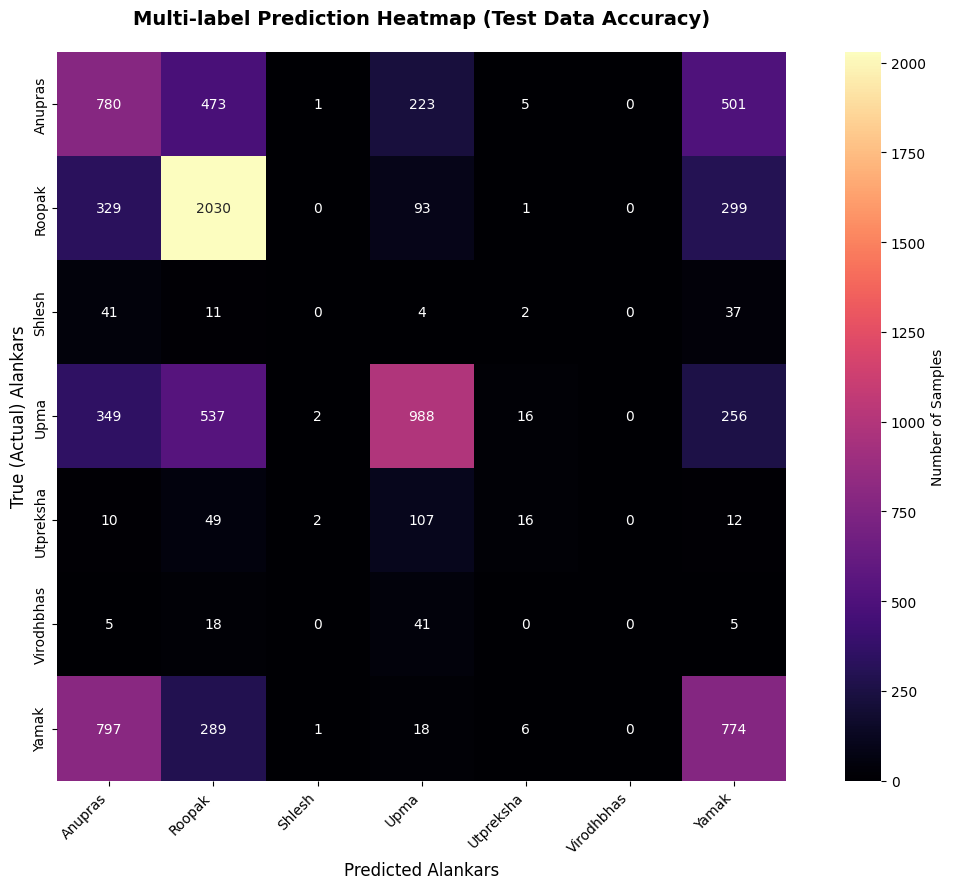

✅ Corrected heatmap using explicit intersection counts is complete.


In [14]:
# ════════════════════════════════════════════════════════════════
# Cell 13 — Multi-label Prediction Heatmap
# ════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Ensure arrays are binary
y_true_arr = np.array(y_val)
y_pred_arr = (np.array(y_pred) >= THRESHOLD).astype(int)

# 2. Initialize intersection matrix (num_classes x num_classes)
multilabel_cm = np.zeros((num_classes, num_classes))

# 3. Explicit intersection count (Row = Actual, Column = Predicted)
for i in range(num_classes):       # i = True Label index
    for j in range(num_classes):   # j = Predicted Label index
        intersection = np.sum((y_true_arr[:, i] == 1) & (y_pred_arr[:, j] == 1))
        multilabel_cm[i, j] = intersection

# 4. Plot the Heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(
    multilabel_cm,
    annot=True,
    fmt=".0f",
    cmap="magma",
    xticklabels=mlb.classes_,
    yticklabels=mlb.classes_,
    square=True,
    cbar_kws={"label": "Number of Samples"}
)

plt.title("Multi-label Prediction Heatmap (Test Data Accuracy)", fontsize=14, pad=20, fontweight='bold')
plt.xlabel("Predicted Alankars", fontsize=12)
plt.ylabel("True (Actual) Alankars", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig(os.path.join(CFG["save_dir"], "corrected_test_heatmap.png"), dpi=300)
plt.show()

print("✅ Corrected heatmap using explicit intersection counts is complete.")

# 🔲 Cell 14 — Confusion Matrix Heatmaps (Per Label — Test Data)
Each cell shows:  count and row percentage.

Generating Confusion Matrix Heatmaps (based on test/validation data)...


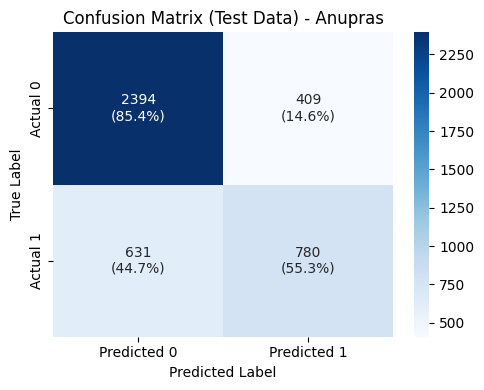

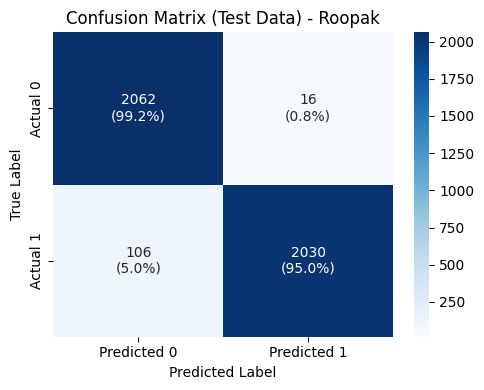

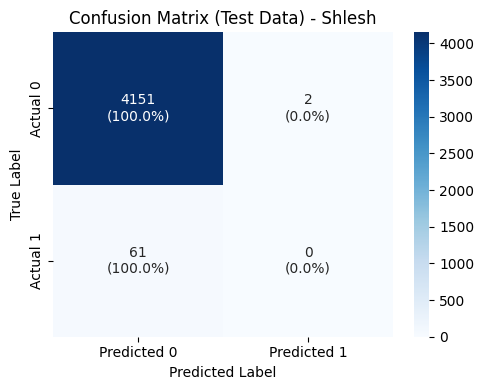

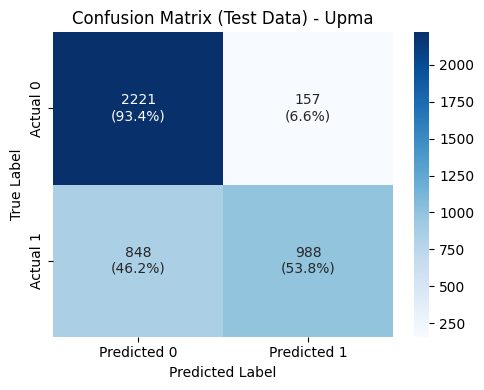

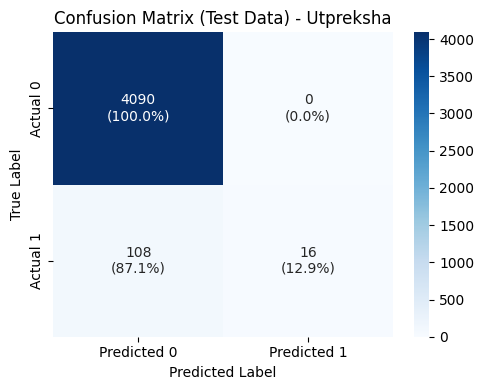

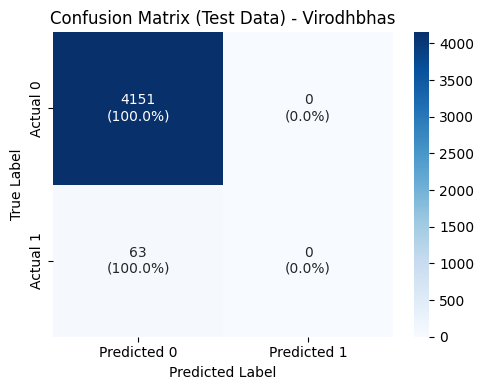

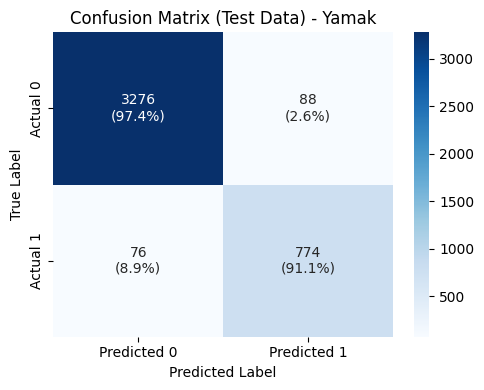

✅ Confusion matrices (test data) saved as PNG and CSV.


In [15]:
print("Generating Confusion Matrix Heatmaps (based on test/validation data)...")
conf_matrices = multilabel_confusion_matrix(y_val, y_pred)

for i, label in enumerate(mlb.classes_):
    cm = conf_matrices[i]
    cm_df = pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )
    csv_path = os.path.join(CFG["save_dir"], f"confusion_matrix_{label}.csv")
    cm_df.to_csv(csv_path)

    # Annotation: count + row percentage
    cm_sum  = cm.sum(axis=1, keepdims=True)
    cm_perc = np.divide(cm.astype(float), cm_sum, where=cm_sum != 0) * 100
    annot   = np.array([
        [f"{v}\n({cm_perc[r, c]:.1f}%)" for c, v in enumerate(row)]
        for r, row in enumerate(cm)
    ])

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        xticklabels=["Predicted 0", "Predicted 1"],
        yticklabels=["Actual 0", "Actual 1"]
    )
    plt.title(f"Confusion Matrix (Test Data) - {label}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    png_path = os.path.join(CFG["save_dir"], f"confusion_matrix_{label}.png")
    plt.savefig(png_path, dpi=300)
    plt.show()

print("✅ Confusion matrices (test data) saved as PNG and CSV.")

# 📈 Cell 15 — Plot Training History (Accuracy & Loss)

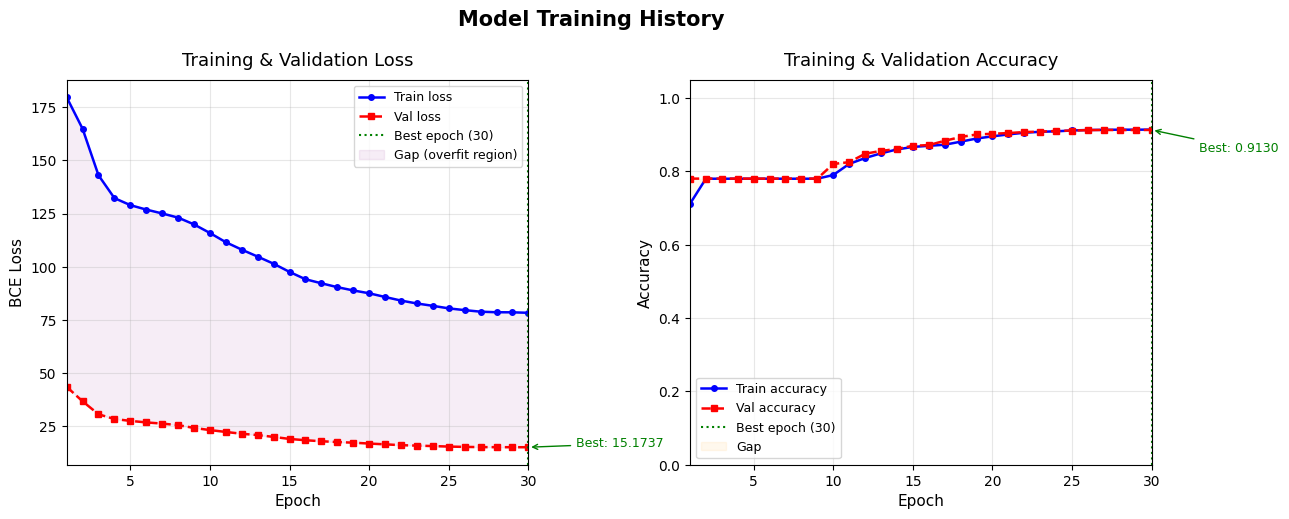

✅ Training history graphs saved.
   Best epoch        : 30
   Best val loss     : 15.1737
   Best val accuracy : 0.9130


In [16]:
# ═══════════════════════════════════════════════════════════
# Cell 15 — Training History: Accuracy & Loss Graphs
# ═══════════════════════════════════════════════════════════
import matplotlib.gridspec as gridspec

epochs_ran = range(1, len(train_loss_hist) + 1)
best_epoch_idx = int(np.argmin(val_loss_hist))

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# ── Left: Loss ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(epochs_ran, train_loss_hist, 'b-o',  markersize=4, linewidth=1.8, label='Train loss')
ax1.plot(epochs_ran, val_loss_hist,   'r--s', markersize=4, linewidth=1.8, label='Val loss')
ax1.axvline(best_epoch_idx + 1, color='green', linestyle=':', linewidth=1.5,
            label=f'Best epoch ({best_epoch_idx + 1})')
ax1.fill_between(epochs_ran, train_loss_hist, val_loss_hist, alpha=0.07, color='purple',
                 label='Gap (overfit region)')
ax1.set_title('Training & Validation Loss', fontsize=13, pad=10)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('BCE Loss', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1, len(epochs_ran))

best_val_loss = val_loss_hist[best_epoch_idx]
ax1.annotate(
    f'Best: {best_val_loss:.4f}',
    xy=(best_epoch_idx + 1, best_val_loss),
    xytext=(best_epoch_idx + 1 + max(1, len(epochs_ran)//8), best_val_loss + 0.01),
    arrowprops=dict(arrowstyle='->', color='green'),
    fontsize=9, color='green'
)

# ── Right: Accuracy ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(epochs_ran, train_acc_hist, 'b-o',  markersize=4, linewidth=1.8, label='Train accuracy')
ax2.plot(epochs_ran, val_acc_hist,   'r--s', markersize=4, linewidth=1.8, label='Val accuracy')
ax2.axvline(best_epoch_idx + 1, color='green', linestyle=':', linewidth=1.5,
            label=f'Best epoch ({best_epoch_idx + 1})')
ax2.fill_between(epochs_ran, train_acc_hist, val_acc_hist, alpha=0.07, color='orange', label='Gap')
ax2.set_title('Training & Validation Accuracy', fontsize=13, pad=10)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(1, len(epochs_ran))
ax2.set_ylim(0, 1.05)

best_val_acc = val_acc_hist[best_epoch_idx]
ax2.annotate(
    f'Best: {best_val_acc:.4f}',
    xy=(best_epoch_idx + 1, best_val_acc),
    xytext=(best_epoch_idx + 1 + max(1, len(epochs_ran)//8), best_val_acc - 0.06),
    arrowprops=dict(arrowstyle='->', color='green'),
    fontsize=9, color='green'
)

plt.suptitle('Model Training History', fontsize=15, fontweight='bold', y=1.02)
plt.savefig(os.path.join(CFG["save_dir"], 'training_history.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training history graphs saved.")
print(f"   Best epoch        : {best_epoch_idx + 1}")
print(f"   Best val loss     : {best_val_loss:.4f}")
print(f"   Best val accuracy : {best_val_acc:.4f}")

# ⏱ Cell 16 — Total Runtime & Output Summary

In [17]:
total_seconds = time.time() - training_start_time
hours   = int(total_seconds // 3600)
minutes = int((total_seconds % 3600) // 60)
seconds = int(total_seconds % 60)

with open(os.path.join(CFG["save_dir"], "runtime.txt"), "w") as f:
    f.write(f"{hours}h {minutes}m {seconds}s")

print("\n" + "="*50)
print(f"⏱  TOTAL RUNTIME: {hours}h {minutes}m {seconds}s")
print("="*50)

print("\n✅ All outputs saved to", CFG['save_dir'])
print("   - best_model.pt")
print("   - corrected_test_heatmap.png")
print("   - confusion_matrix_<label>.png / .csv")
print("   - training_history.png")
print("   - runtime.txt")


⏱  TOTAL RUNTIME: 0h 47m 43s

✅ All outputs saved to /kaggle/working/alankar_model
   - best_model.pt
   - corrected_test_heatmap.png
   - confusion_matrix_<label>.png / .csv
   - training_history.png
   - runtime.txt


# 🔮 Cell 17 — Test on Unseen Data
Run this AFTER the model training completes. Predict Alankars on new, unseen Hindi text.

In [18]:
# ════════════════════════════════════════════════════════════════════════════════
# Cell 17 — Test on Unseen Data
# (Run this AFTER the model training completes)
# ════════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd

# ════════════════════════════════════════════════════════════════════════════════
# ↓↓↓ REPLACE THESE WITH YOUR OWN UNSEEN HINDI SENTENCES ↓↓↓
# ════════════════════════════════════════════════════════════════════════════════
unseen_texts = [
    "उसका चेहरा चाँद जैसा उजाला है,",
    "मंद-मंद मुस्कान मन को भाया है,",
    "चंचल चितवन चुरा ले गई दिल को,",
    "उसकी बातें जैसे मधुर रस की धारा हैं,",
    "वह तो जीवन का सूरज बन आया है।"
]
# ════════════════════════════════════════════════════════════════════════════════

# ── Step 1: Tokenize unseen texts ──
enc = tokenizer(
    unseen_texts,
    padding=True,
    truncation=True,
    max_length=CFG["max_len"]
)

input_ids_unseen      = torch.tensor(enc["input_ids"]).to(DEVICE)
attention_mask_unseen = torch.tensor(enc["attention_mask"]).to(DEVICE)

# ── Step 2: Predict ──
model.eval()
with torch.no_grad():
    logits_unseen  = model(input_ids_unseen, attention_mask_unseen)
    proba_unseen   = torch.sigmoid(logits_unseen).cpu().numpy()

y_pred_unseen = (proba_unseen >= THRESHOLD).astype(int)

# ── Step 3: Display results ──
print("\n" + "="*70)
print(" "*15 + "UNSEEN DATA — ALANKAR PREDICTIONS")
print("="*70)

for i, text in enumerate(unseen_texts):
    detected = [mlb.classes_[j] for j in range(len(mlb.classes_)) if y_pred_unseen[i][j] == 1]
    print(f"\n📝 Text     : {text}")
    print(f"🎯 Alankars : {detected if detected else ['None detected']}")
    prob_str = " | ".join(
        [f"{mlb.classes_[j]}: {proba_unseen[i][j]:.3f}" for j in range(len(mlb.classes_))]
    )
    print(f"📊 Proba    : {prob_str}")

print("\n" + "="*70)

# ── Step 4: Save to Excel ──
results_df = pd.DataFrame({
    "Text": unseen_texts,
    "Predicted Alankars": [
        ", ".join([mlb.classes_[j] for j in range(len(mlb.classes_)) if y_pred_unseen[i][j] == 1]) or "None"
        for i in range(len(unseen_texts))
    ]
})

for j, cls in enumerate(mlb.classes_):
    results_df[f"P({cls})"] = [round(float(proba_unseen[i][j]), 4) for i in range(len(unseen_texts))]

output_path = os.path.join(CFG["save_dir"], "unseen_predictions.xlsx")
results_df.to_excel(output_path, index=False)
print(f"\n✅ Predictions saved to: {output_path}")
print("\n" + results_df[["Text", "Predicted Alankars"]].to_string(index=False))


               UNSEEN DATA — ALANKAR PREDICTIONS

📝 Text     : उसका चेहरा चाँद जैसा उजाला है,
🎯 Alankars : ['Roopak']
📊 Proba    : Anupras: 0.116 | Roopak: 0.904 | Shlesh: 0.002 | Upma: 0.367 | Utpreksha: 0.008 | Virodhbhas: 0.008 | Yamak: 0.018

📝 Text     : मंद-मंद मुस्कान मन को भाया है,
🎯 Alankars : ['Anupras', 'Roopak', 'Yamak']
📊 Proba    : Anupras: 0.562 | Roopak: 0.686 | Shlesh: 0.151 | Upma: 0.323 | Utpreksha: 0.096 | Virodhbhas: 0.098 | Yamak: 0.602

📝 Text     : चंचल चितवन चुरा ले गई दिल को,
🎯 Alankars : ['None detected']
📊 Proba    : Anupras: 0.466 | Roopak: 0.107 | Shlesh: 0.004 | Upma: 0.448 | Utpreksha: 0.004 | Virodhbhas: 0.006 | Yamak: 0.156

📝 Text     : उसकी बातें जैसे मधुर रस की धारा हैं,
🎯 Alankars : ['Roopak', 'Upma']
📊 Proba    : Anupras: 0.224 | Roopak: 0.641 | Shlesh: 0.120 | Upma: 0.538 | Utpreksha: 0.381 | Virodhbhas: 0.266 | Yamak: 0.129

📝 Text     : वह तो जीवन का सूरज बन आया है।
🎯 Alankars : ['Roopak']
📊 Proba    : Anupras: 0.130 | Roopak: 0.908 | Shlesh: 